<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/satisfaction.png'/></center>

### **고객 만족도 예측을 통한 서비스 개선**
# **단계 2: 기본 모델링**

## **미션 설명**

- 이번 단계에서는 다음과 같이 2개의 미션을 수행합니다.

### 미션 6: 전처리

- 다음과 같은 이유로 0 ~ 5 정수를 갖는 변수를 가변수화 합니다.
    - 0점은 '매우 불만족'보다 낮은 점수가 아니라 '해당 없음'을 의미하는 경우가 많습니다.
    - 만약 0, 1, 2, 3, 4, 5 그대로 넣으면, 모델은 0을 1보다 더 나쁜 것으로 학습하여 예측에 오류가 생길 수 있습니다.
    - 만족도 1점과 2점의 차이가 4점과 5점의 차이와 물리적으로 동일하지 않습니다.
    - 가변수화를 하면 모델이 각 점수를 독립적으로 학습할 수 있어 더 유연한 모델이 될 것입니다.
- 모델링을 위해 x, y로 분리하고 학습용/검증용 데이터로 분리합니다.
- 스케일링을 수행합니다.

### 미션 7: 모델링

- 4개 이상의 딥러닝 모델을 만들어 성능을 확인합니다.
- 모델 이름은 model1, model2, model3, model4...로 구분합니다.
- 마지막 모델의 경우 예측 성능을 높이기 위해 다양한 시도를 해봅니다.
- 가장 성능이 좋은 모델을 저장합니다.

## **※ 코드 셀은 충분히 추가해 사용합니다.**

## **1. 환경설정**

### (1) 구글 드라이브 연결 및 경로 설정

- 다음 구문을 실행에 구글 코랩에서 사용 가능하게 연결합니다.

In [13]:
# 구글 드라이브 연결 & 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/KT-A/1-Data/project01/'
else:
    path = ''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### (2) 라이브러리 불러오기

- 이후에 사용할 라이브러리를 모두 불러옵니다.

In [14]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import *

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.backend import clear_session
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (3) 학습 곡선 시각화 함수 만들기

- 모델링 수행 시 학습 상황을 시각화해 확인하기 위한 함수를 만듭니다.

In [15]:
# 함수 만들기
def dl_history_plot(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history['loss'], label='Train Loss', marker='.')
    plt.plot(history['val_loss'], label='Validation Loss', marker='.')

    plt.title('Learning Curve', size=15, pad=20)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

### (4) 데이터 불러오기

- 이전 과정에서 저장한 파일을 읽어와 **data** 데이터프레임을 만듭니다.
    - path + 'data.csv' --> data
    

In [16]:
# 파일 읽어오기
data = pd.read_csv(path + 'data.csv')

## **2. 미션 6: 전처리**

- 결측치 처리는 이전 과정에서 완료가 된 상태입니다.
- 딥러닝 모델링을 위해 필요한 전처리를 수행합니다.

### (1) 가변수화

- 0 ~ 5 정수를 갖는 변수를 가변수화 합니다.
- 대상 변수는 'Inflight wifi service'부터 'Cleanliness'까지 14개 입니다.
- 일관된 가변수화 결과를 위해 Category 형 변수로 변환합니다.

In [17]:
# 설문 범주 정의
categories = [0, 1, 2, 3, 4, 5]

# 가변수화 대상 변수
dumm_cols = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location',
             'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service',
             'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']

# Category 형 변수로 변환
for col in dumm_cols:
    data[col] = pd.Categorical(data[col], categories=categories)

# 가변수화
data = pd.get_dummies(data, columns=dumm_cols, drop_first=True, dtype=int)

# 확인
print(data.shape)
print(data.head())

(19278, 79)
   Gender  Customer Type   Age  Type of Travel  Class  Flight Distance  \
0       1              1  35.0               0      1              349   
1       0              1  40.0               0      0              920   
2       0              1  52.0               0      0             3979   
3       1              1  47.0               0      1              141   
4       1              1  33.0               0      0             3153   

   Departure Delay in Minutes  Arrival Delay in Minutes  Satisfaction  \
0                           0                       0.0             1   
1                          10                       3.0             1   
2                          21                       7.0             1   
3                         142                     158.0             1   
4                           0                       0.0             1   

   Inflight wifi service_1  ...  Inflight service_1  Inflight service_2  \
0                        0  .

### (2) 데이터 분할

- x, y를 분리한 후 학습용/검증용 데이터를 8:2로 분리합니다.

In [18]:
target= 'Satisfaction'
x = data.drop(target, axis=1)
y = data.loc[:, target]

In [19]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

### (3) 스케일링

- MinMaxScaler()를 사용해 스케일링을 수행합니다.

In [20]:
scaler = MinMaxScaler()
scaler.fit_transform(x_train)
scaler.transform(x_val)

array([[1.        , 1.        , 0.38461538, ..., 0.        , 0.        ,
        1.        ],
       [1.        , 0.        , 0.25641026, ..., 0.        , 1.        ,
        0.        ],
       [1.        , 1.        , 0.46153846, ..., 1.        , 0.        ,
        0.        ],
       ...,
       [0.        , 1.        , 0.56410256, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.48717949, ..., 0.        , 0.        ,
        1.        ],
       [0.        , 1.        , 0.53846154, ..., 0.        , 0.        ,
        0.        ]])

## **3. 미션 7: 모델링**

- 다음과 같이 4개 이상의 모델을 만들고 성능을 확인합니다.
    - 모델 1: Base line 모델(Hidden Layer 없이 모델 생성)
    - 모델 2: 복잡한 모델 생성(최소 5개 이상의 Hidden Layer 추가)
    - 모델 3 ~ n: 모델 튜닝(학습률, epoch 조정, Dropout, Early Stopping 등 모델 성능을 높이기 위한 다양한 시도)


### (1) 모델 1

- 우선 모델을 선언합니다.

In [21]:
clear_session()

nfeatures = x_train.shape[1]
model1 = Sequential([
    Input((nfeatures,)),
    Dense(1, activation='sigmoid')
])

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            79 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79 (316.00 B)

 Trainable params: 79 (316.00 B)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [22]:
model1.compile(optimizer=Adam(learning_rate=0.005), loss='binary_crossentropy')
hist = model1.fit(x_train, y_train, epochs=50, validation_split=0.2, verbose=0).history

- 학습 곡선을 확인합니다.

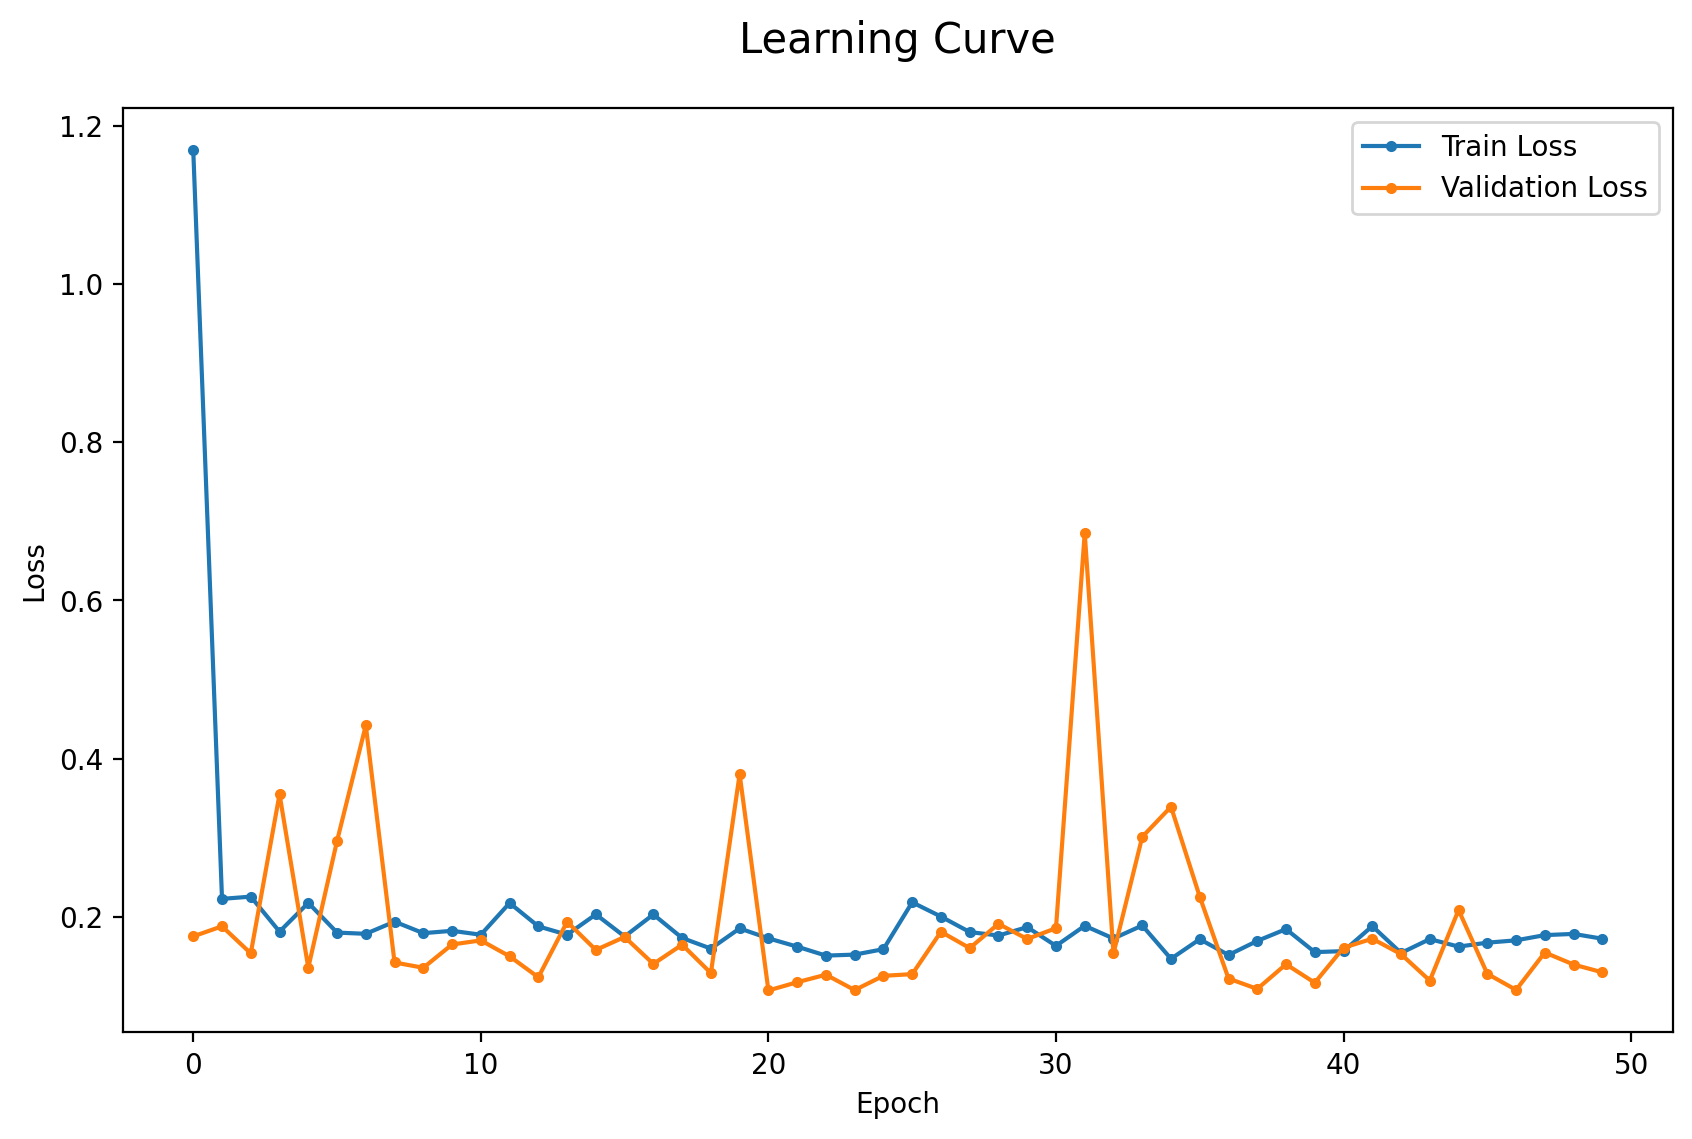

In [23]:
dl_history_plot(hist)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [24]:
y_pred = model1.predict(x_val)
y_pred = np.where(y_pred > 0.5, 1, 0)
print(classification_report(y_val, y_pred))

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
              precision    recall  f1-score   support

           0       0.73      0.80      0.77       397
           1       0.98      0.97      0.97      3459

    accuracy                           0.95      3856
   macro avg       0.85      0.88      0.87      3856
weighted avg       0.95      0.95      0.95      3856



> 다른 방법도 있습니다.
```python
# 확률값 --> 0, 1 변환
y_pred = (y_pred > 0.5).astype('int')

# y_pred = np.where(y_pred > 0.5, 1, 0)
print(classification_report(y_val, y_pred))
```

### (2) 모델 2

- 모델을 선언합니다.

---

- 참고할만한 모델
```python
model2 = Sequential([
    Input((nfeatures, )),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
```

            Precision recall f1-score support
0               0.87    0.79    0.83    397  
1               0.98    0.99    0.98    3459
ac - 0.97
macro avg -     0.92    0.89    0.90    3856

---

In [25]:
clear_session()

nfeatures = x_train.shape[1]
model2 = Sequential([
    Input((nfeatures, )),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,489 (248.00 KB)

 Trainable params: 63,489 (248.00 KB)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [26]:
model2.compile(optimizer=Adam(learning_rate=0.005), loss='binary_crossentropy')
hist = model2.fit(x_train, y_train, epochs=50, validation_split=0.2, verbose=0).history

- 학습 곡선을 확인합니다.

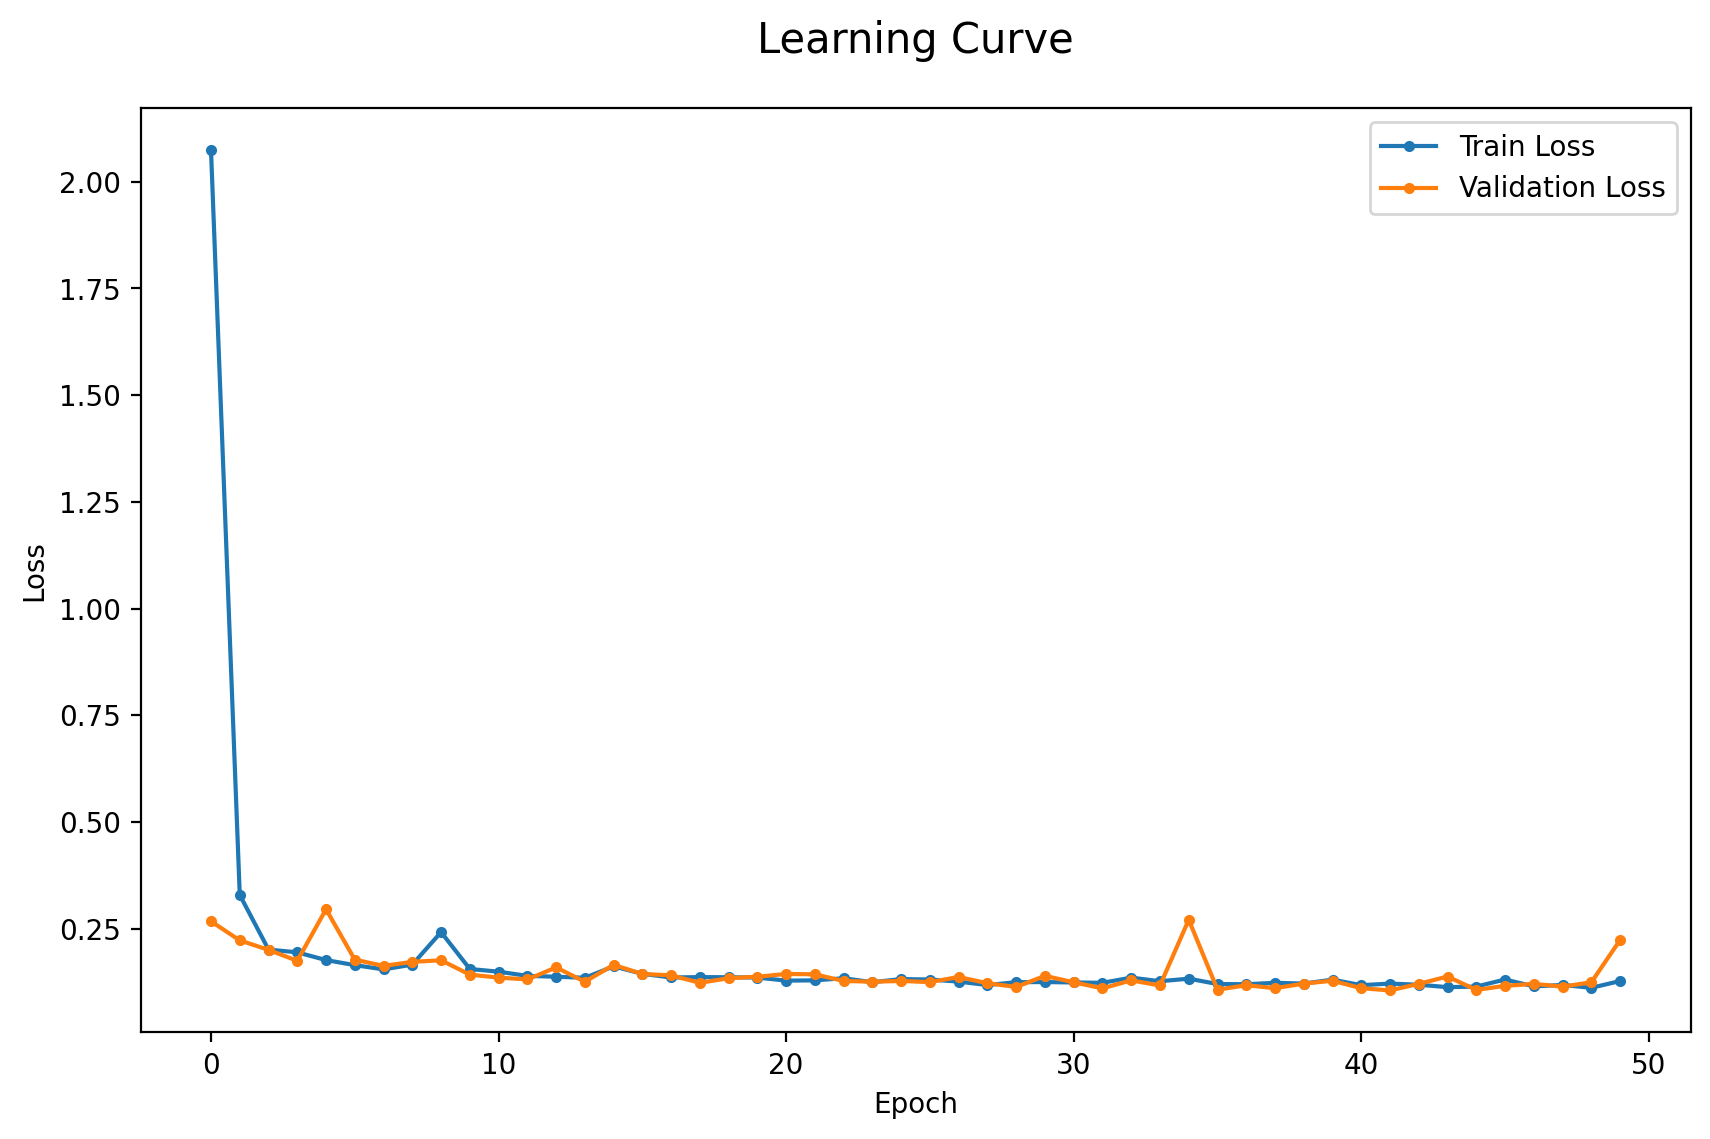

In [27]:
dl_history_plot(hist)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [28]:
y_pred = model2.predict(x_val)
y_pred = np.where(y_pred > 0.5, 1, 0)
print(classification_report(y_val, y_pred))

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.54      0.87      0.67       397
           1       0.98      0.91      0.95      3459

    accuracy                           0.91      3856
   macro avg       0.76      0.89      0.81      3856
weighted avg       0.94      0.91      0.92      3856



### (3) 모델 3: Dropout

- 모델을 선언합니다.

In [29]:
clear_session()

nfeatures = x_train.shape[1]
model3 = Sequential([
    Input((nfeatures, )),
    Dense(256, activation='relu'),
    Dropout(0.3), # dropout 값을 줄이면서 진행 or 0.3~0.5로 우리는 진행했었음
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,489 (248.00 KB)

 Trainable params: 63,489 (248.00 KB)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [30]:
model3.compile(optimizer=Adam(learning_rate=0.005), loss='binary_crossentropy')
hist = model3.fit(x_train, y_train, epochs=50, validation_split=0.2, verbose=0).history

- 학습 곡선을 확인합니다.

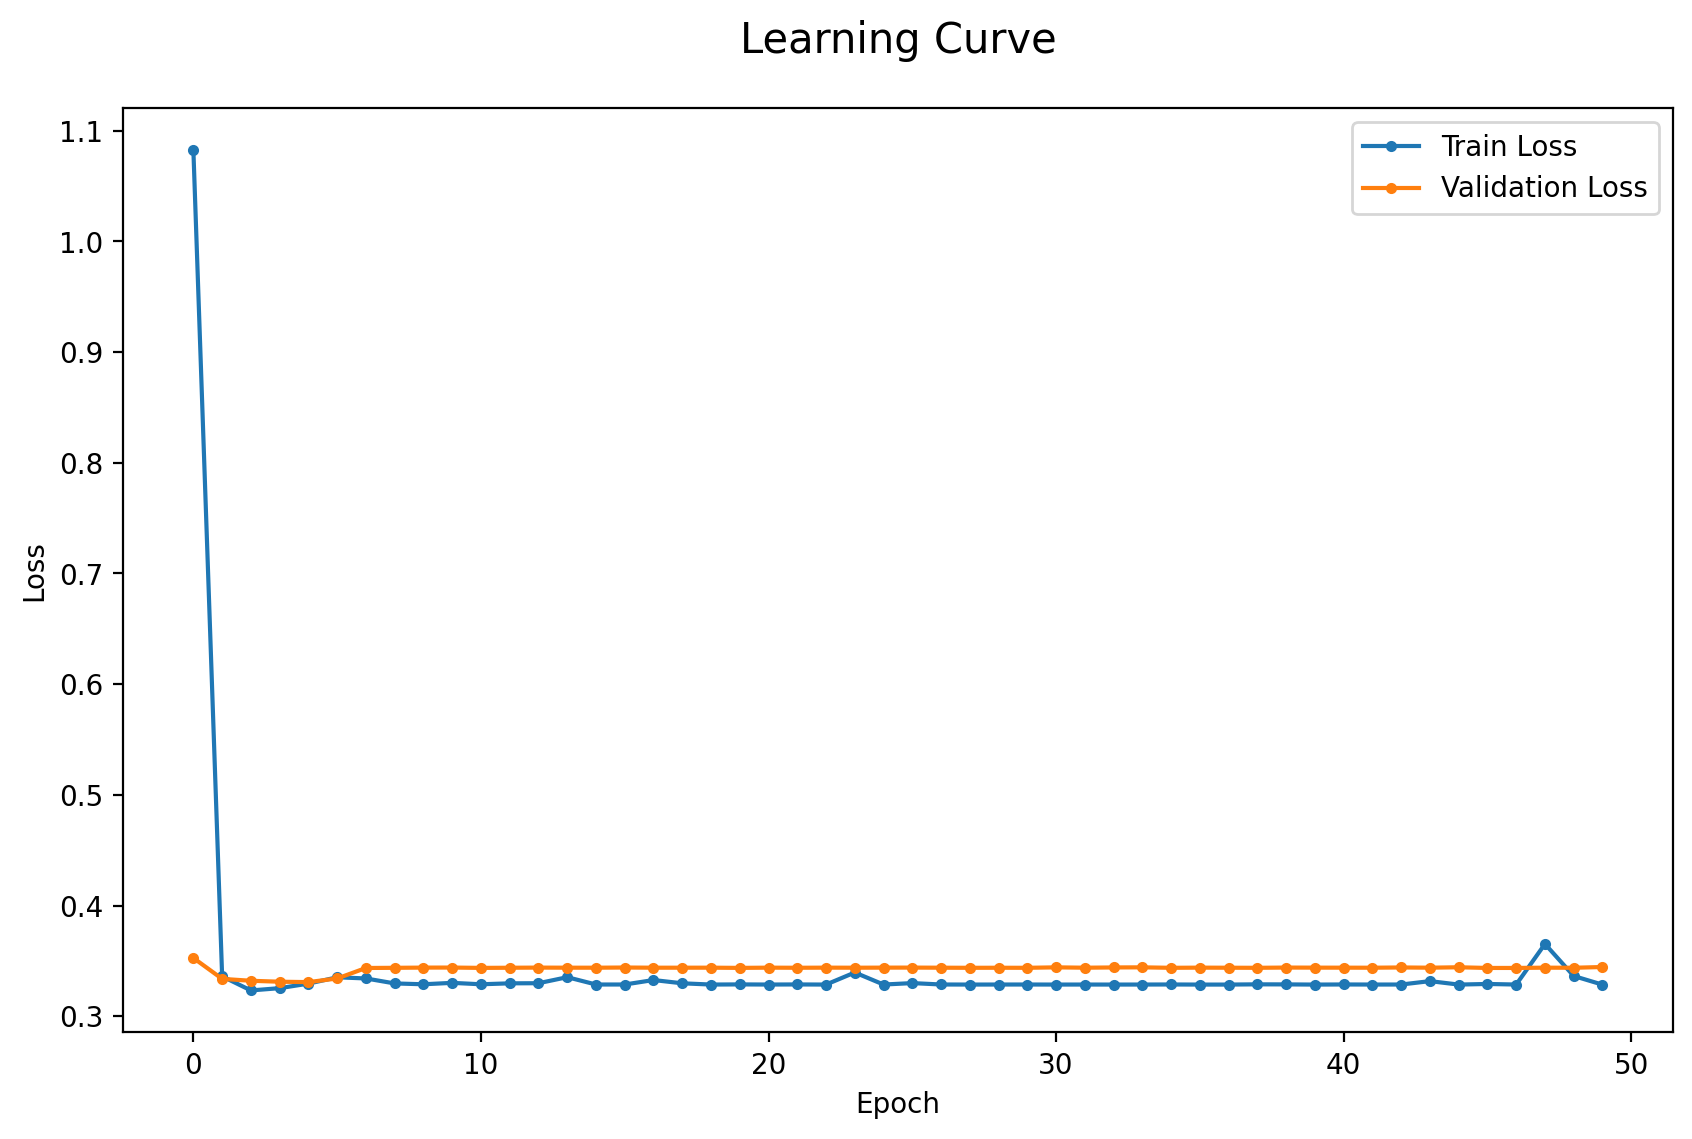

In [31]:
dl_history_plot(hist)

---

> 다른 코드와 비교

```python
model4.compile(optimizer = Adam(learning_rate=0.01), loss='binary_crossentropy')

hist = model4.fit(x_train, y_train, epochs=50, validation_split=0.2, verbose=0).history
```
- 학습률이 클 수록 과적합이 더 크게 보였음

---

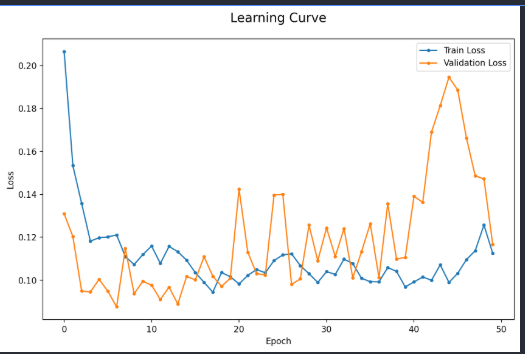

- 검증 데이터로 예측을 수행하고 성능을 확인합니다.

In [32]:
y_pred = model3.predict(x_val)
y_pred = np.where(y_pred > 0.5, 1, 0)
print(classification_report(y_val, y_pred))

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       397
           1       0.90      1.00      0.95      3459

    accuracy                           0.90      3856
   macro avg       0.45      0.50      0.47      3856
weighted avg       0.80      0.90      0.85      3856



### (4) 모델 4: Early Stopping

- 모델을 선언합니다.

---

```
# 코드로 형식 지정됨
```

#### 현준님 코드 참고해보세용 (class 가중치) - 제일 높은 결과값입니다.

```python
# 메모리 정리
clear_session()

# 입력 Feature 수
nfeatures = x.shape[1]

# Sequential 모델 선언
model4 = Sequential([
    Input(shape=(nfeatures, )),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# 모델 요약
model4.summary()
```

```python
# 학습 설정
model4.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', min_delta=0.01, patience=7, restore_best_weights=True, verbose=1)
```

```python
# 1. 클래스 가중치 설정 (불만족 0번에 10배 중요도 부여)
class_weights = {0: 10.0, 1: 1.0}

# 2. 모델 학습 (검증 데이터와 가중치 통합)
hist = model4.fit(x_train, y_train,
                 epochs=50,
                 batch_size=64,              # 곡선을 매끄럽게 하기 위해 64 추천
                 validation_data=(x_val, y_val), # 분리해둔 검증셋 사용
                 class_weight=class_weights,    # 불균형 해소를 위한 가중치 적용
                 verbose=1)

```

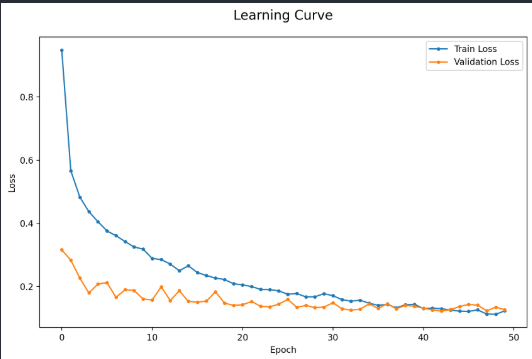

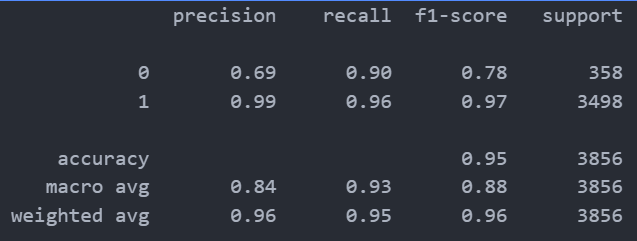


---

---

#### 채은님 코드 참고해보세용 (L2 정규화 사용!)
```python

#모델 선언
model6 = Sequential([
    Input((nfeatures, )),
    Dense(128, activation='relu',kernel_regularizer=l2(0.05)),
    Dense(128, activation='relu',kernel_regularizer=l2(0.05)),
    Dense(64, activation='relu',kernel_regularizer=l2(0.05)),
    Dense(64, activation='relu',kernel_regularizer=l2(0.05)),
    Dense(32, activation='relu',kernel_regularizer=l2(0.05)),
    Dense(32, activation='relu',kernel_regularizer=l2(0.05)),
    Dense(16, activation='relu',kernel_regularizer=l2(0.05)),
    Dense(1, activation='sigmoid')
])

model6.summary()

from tensorflow.keras.callbacks import EarlyStopping

# 학습 설정
model6.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy')
es = EarlyStopping(monitor='val_loss', min_delta=0.01, patience=10, restore_best_weights=True, verbose=1)

# 학습
hist = model6.fit(x_train, y_train, epochs=50, validation_split=0.2, callbacks=[es], verbose=1).history


```

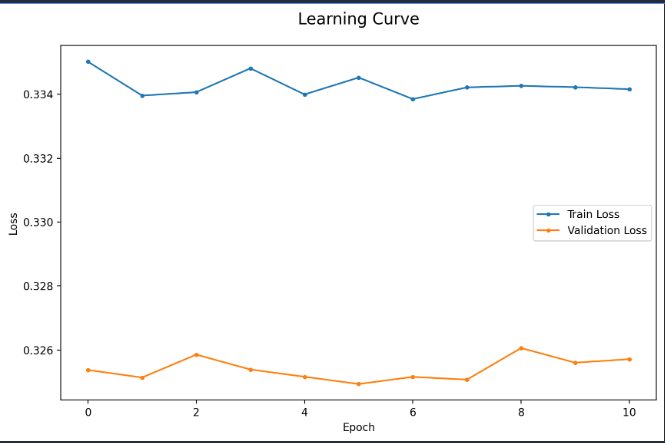

---

In [33]:
clear_session()

nfeatures = x_train.shape[1]
model4 = Sequential([
    Input((nfeatures, )),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,489 (248.00 KB)

 Trainable params: 63,489 (248.00 KB)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [34]:
early_stopping = EarlyStopping(monitor='val_loss', min_delta=0.01, patience=10, verbose=1) # early_stopping 파라미터 조정 확인하면서 돌려보세요!
model4.compile(optimizer=Adam(learning_rate=0.005), loss='binary_crossentropy')
hist = model4.fit(x_train, y_train, epochs=100, validation_split=0.2, verbose=1, callbacks=[early_stopping]).history

Epoch 1/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.7735 - val_loss: 0.2977
Epoch 2/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2537 - val_loss: 0.2460
Epoch 3/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2008 - val_loss: 0.1624
Epoch 4/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2105 - val_loss: 0.2522
Epoch 5/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2183 - val_loss: 0.1802
Epoch 6/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1693 - val_loss: 0.1962
Epoch 7/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1693 - val_loss: 0.1435
Epoch 8/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1551 - val_loss: 0.1291
Epoch 9/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2463 - val_loss: 0.1357
Epoch 10/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1653 - val_loss: 0.1915
Epoch 11/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1616 - val_loss: 0.1244
Epoch 12/100
386/386 ━━━━━━━━━━━━━━━━━━━━

- 학습 곡선을 확인합니다.

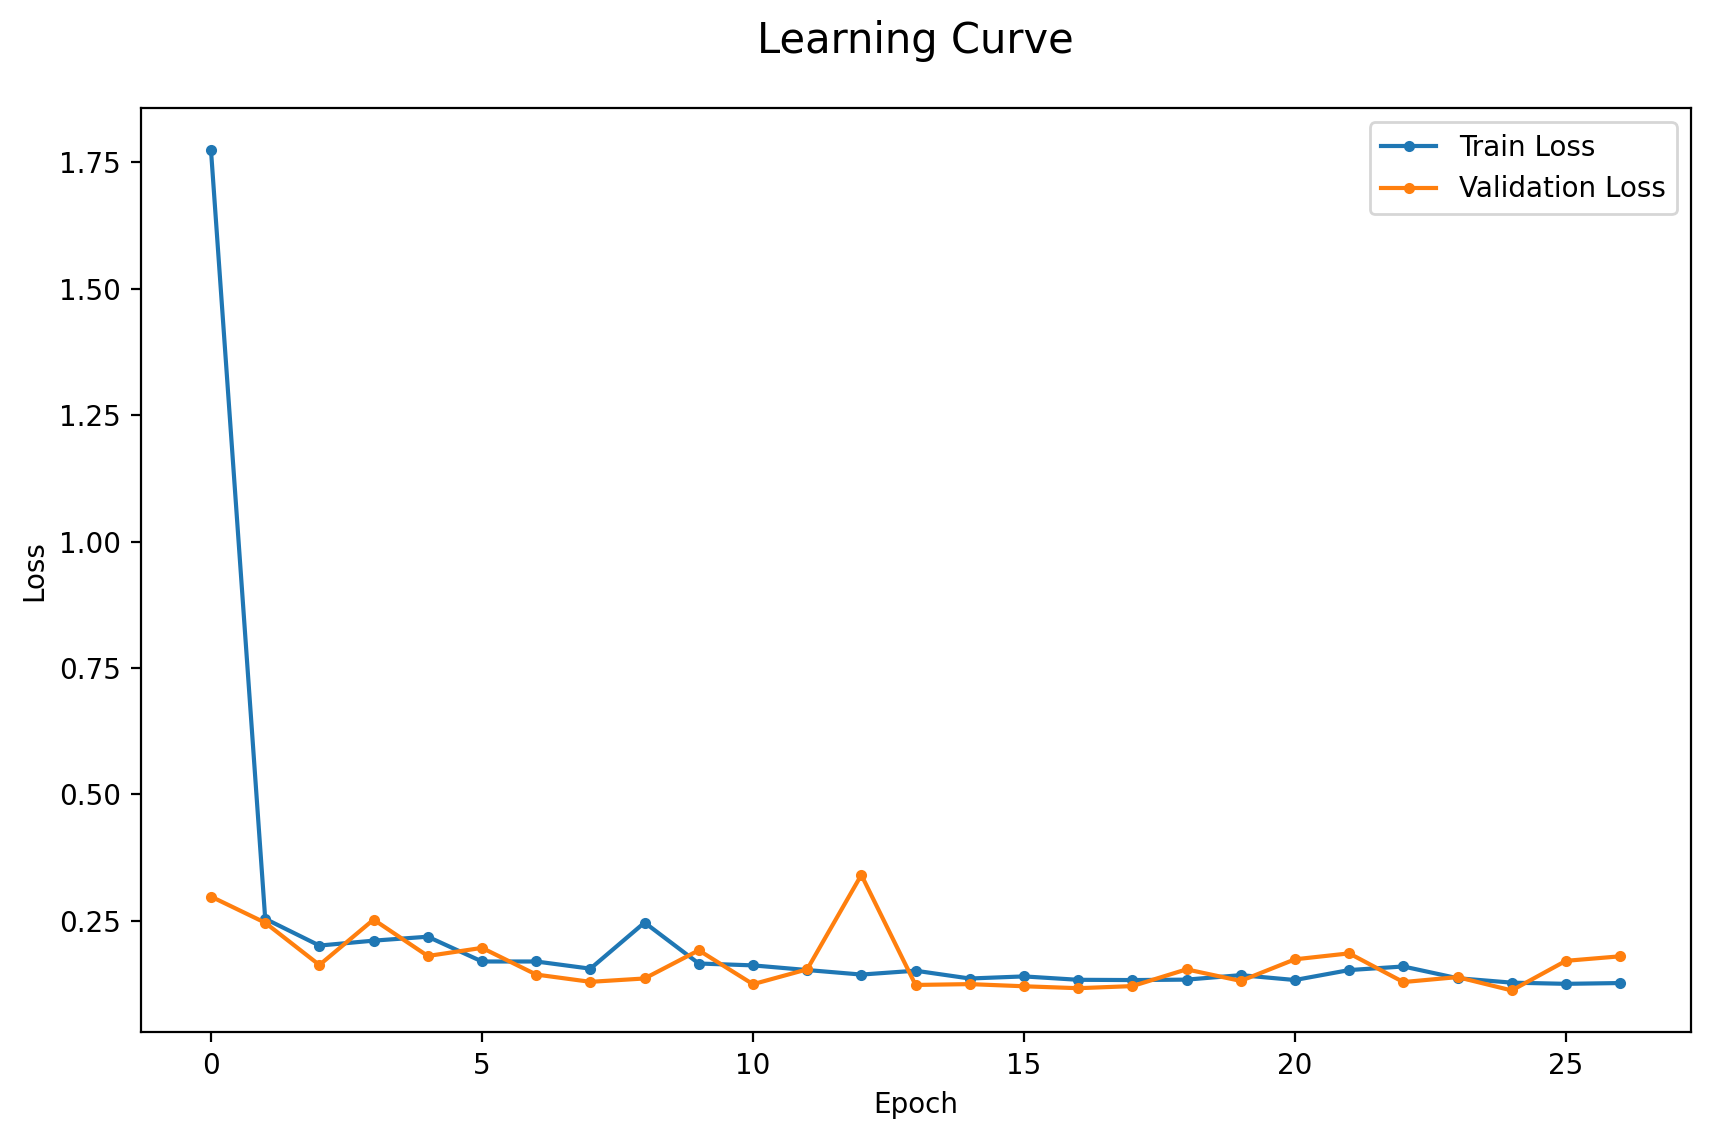

In [35]:
dl_history_plot(hist)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [36]:
y_pred = model4.predict(x_val)
y_pred = np.where(y_pred > 0.5, 1, 0)
print(classification_report(y_val, y_pred))

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
              precision    recall  f1-score   support

           0       0.99      0.36      0.52       397
           1       0.93      1.00      0.96      3459

    accuracy                           0.93      3856
   macro avg       0.96      0.68      0.74      3856
weighted avg       0.94      0.93      0.92      3856



In [37]:
# 1. 확률값
y_prob = model4.predict(x_val).ravel()

best_t = 0.5
best_f1 = 0

# 2. threshold 탐색
for t in np.arange(0.1, 0.91, 0.01):
    y_pred = (y_prob >= t).astype(int)
    f1 = f1_score(y_val, y_pred, pos_label=0)  # 핵심: 0클래스 기준

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1 (class 0):", best_f1)

# 3. 최적 threshold 적용
y_pred = (y_prob >= best_t).astype(int)
print(classification_report(y_val, y_pred))

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Best threshold: 0.8699999999999996
Best F1 (class 0): 0.7329974811083123
              precision    recall  f1-score   support

           0       0.73      0.73      0.73       397
           1       0.97      0.97      0.97      3459

    accuracy                           0.95      3856
   macro avg       0.85      0.85      0.85      3856
weighted avg       0.95      0.95      0.95      3856



### (5) 저장

- 학습용 데이터 스케일링에 사용한 스케일러를 **scaler.pkl** 파일로 저장합니다.
- **joblib.dump()** 함수를 사용합니다.

In [38]:
# 스케일러 저장
joblib.dump(scaler, path + 'scaler.pkl')

['/content/drive/MyDrive/KT-A/1-Data/project01/scaler.pkl']

- 성능이 가장 높은 모델을 **base_model.keras** 파일로 저장합니다.
- **save()** 메서드를 사용합니다.

In [39]:
# 모델 저장
model4.save(path + 'base_model.keras')